# Notebook 7: MovieLens ABT Descriptive Data Analysis

## Learning Objectives
- Load and analyze MovieLens movie dataset
- Parse multi-genre movie data
- Count movies by genre
- Create visualizations
- Export results to Excel

## What's New:
- **Pure Data Analysis** - No LLM needed!
- **MovieLens Dataset** - Real movie data with genres
- **Genre Analysis** - Count movies per genre
- **Excel Export** - Professional output tables
- **Visualizations** - Charts and graphs

## Dataset:
- **File**: `movies.csv` from MovieLens dataset

- **Location**: `data/input/movie_lens/movies.csv`
- **Columns**: movieId, title, genres
- **Genre Format**: Pipe-separated (e.g., "Action|Adventure|Thriller")

## No API Keys Required!
This notebook uses only Pandas, Matplotlib, and Excel export.

## Step 1: Install Required Packages

In [2]:
%pip install pandas matplotlib seaborn openpyxl --quiet

print(" Packages installed")

Note: you may need to restart the kernel to use updated packages.
 Packages installed


## Step 2: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from collections import Counter
import numpy as np
import json

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(" Libraries imported")

 Libraries imported


## Step 3: Load MovieLens Data

**USER INPUT**: Specify the path to your movies.csv file.

In [2]:
# ============================================================================
# USER INPUT: Specify Movies ABT file path
# ============================================================================
movies_file = "../data/outputs/analytics_base_table.csv" 

# Check if file exists
if os.path.exists(movies_file):
 print(f" File found: {movies_file}")
else:
 print(f" File not found: {movies_file}")
 print(f"Current directory: {os.getcwd()}")
 print("\nPlease update the path to your movies.csv file")

 File found: ../data/outputs/analytics_base_table.csv


## Step 4: Load and Explore the Data

In [3]:
# Load the CSV file
movies_df = pd.read_csv(movies_file)

print("=" * 70)
print("MOVIELENS ABT DATASET LOADED")
print("=" * 70)
print(f"\nTotal movies: {len(movies_df):,}")
print(f"Columns: {', '.join(movies_df.columns)}")

print(f"\n{'='*70}")
print("FIRST 10 MOVIES")
print("=" * 70)
display(movies_df.head(10))

MOVIELENS ABT DATASET LOADED

Total movies: 9,742
Columns: Unnamed: 0, movieId, title, genres, avg_rating, number_of_viewers, imdbId, tmdbId

FIRST 10 MOVIES


,Unnamed: 0,movieId,title,genres,avg_rating,number_of_viewers,imdbId,tmdbId
0,0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.920930,215.0,114709,862.0
1,1,2,Jumanji (1995),Adventure|Children|Fantasy,3.431818,110.0,113497,8844.0
2,2,3,Grumpier Old Men (1995),Comedy|Romance,3.259615,52.0,113228,15602.0
3,3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.357143,7.0,114885,31357.0
4,4,5,Father of the Bride Part II (1995),Comedy,3.071429,49.0,113041,11862.0
5,5,6,Heat (1995),Action|Crime|Thriller,3.946078,102.0,113277,949.0
6,6,7,Sabrina (1995),Comedy|Romance,3.185185,54.0,114319,11860.0
7,7,8,Tom and Huck (1995),Adventure|Children,2.875000,8.0,112302,45325.0
8,8,9,Sudden Death (1995),Action,3.125000,16.0,114576,9091.0
9,9,10,GoldenEye (1995),Action|Adventure|Thriller,3.496212,132.0,113189,710.0


## Step 5: Understand the Genre Format

In [4]:
# Show some examples of the genre format
print("=" * 70)
print("GENRE FORMAT EXAMPLES")
print("=" * 70)

sample_movies = movies_df.head(10)[['title', 'genres']]
for idx, row in sample_movies.iterrows():
 print(f"\n{row['title']}")
 print(f" Genres: {row['genres']}")
 print(f" Split: {row['genres'].split('|')}")

GENRE FORMAT EXAMPLES

Toy Story (1995)
  Genres: Adventure|Animation|Children|Comedy|Fantasy
  Split: ['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy']

Jumanji (1995)
  Genres: Adventure|Children|Fantasy
  Split: ['Adventure', 'Children', 'Fantasy']

Grumpier Old Men (1995)
  Genres: Comedy|Romance
  Split: ['Comedy', 'Romance']

Waiting to Exhale (1995)
  Genres: Comedy|Drama|Romance
  Split: ['Comedy', 'Drama', 'Romance']

Father of the Bride Part II (1995)
  Genres: Comedy
  Split: ['Comedy']

Heat (1995)
  Genres: Action|Crime|Thriller
  Split: ['Action', 'Crime', 'Thriller']

Sabrina (1995)
  Genres: Comedy|Romance
  Split: ['Comedy', 'Romance']

Tom and Huck (1995)
  Genres: Adventure|Children
  Split: ['Adventure', 'Children']

Sudden Death (1995)
  Genres: Action
  Split: ['Action']

GoldenEye (1995)
  Genres: Action|Adventure|Thriller
  Split: ['Action', 'Adventure', 'Thriller']


## Step 6a: Parse Genres

Extract individual genres from the pipe-separated format and count occurrences.

In [5]:
# Adjust separator if needed ('|' or ',')
movies_df['Genres_List'] = movies_df['genres'].str.split('|')

# Clean whitespace
movies_df['Genres_List'] = movies_df['Genres_List'].apply(
 lambda x: [genre.strip() for genre in x] if isinstance(x, list) else []
)

## Step 7: Generate Summary

In [6]:
total_movies = len(movies_df)

genre_series = movies_df['Genres_List'].explode()

total_genre_tags = genre_series.count()

genre_counts = Counter(genre_series)

unique_genres = len(genre_counts)

most_common_genre, most_common_count = genre_counts.most_common(1)[0]
least_common_genre, least_common_count = genre_counts.most_common()[-1]

average_tags_per_movie = movies_df['Genres_List'].apply(len).mean()

median_movie_count_per_genre = np.median(list(genre_counts.values()))

summary_stats = {
 'Total Movies': int(total_movies),
 'Total Genre Tags': int(total_genre_tags),
 'Unique Genres': int(unique_genres),
 'Most Common Genre': str(most_common_genre),
 'Most Common Count': int(most_common_count),
 'Least Common Genre': str(least_common_genre),
 'Least Common Count': int(least_common_count),
 'Average Tags per Movie': float(round(average_tags_per_movie, 2)),
 'Median Movie Count per Genre': float(median_movie_count_per_genre)
}


## Step 8: Export to Excel

Create a professional Excel file with the genre counts.

In [ ]:
# --------------------------------
# Save Outputs
# --------------------------------
output_dir = "../data/outputs/"
movies_df.to_csv(os.path.join(output_dir, "analytics_base_table_with_genres_list.csv"), index=False)

with open(os.path.join(output_dir, "summary_stats.json"), "w") as f:
    json.dump(summary_stats, f, indent=4)

pd.DataFrame([summary_stats]).to_csv(
    os.path.join(output_dir, "summary_stats.csv"),
    index=False
)

print(" Processing Complete")
print("Files saved in:", output_dir)
print("\nSummary Statistics:")
print(summary_stats)

## Step 9: Visualize Genre Distribution

Create a bar chart showing the top genres.

In [8]:
# Convert Counter to DataFrame
genre_df = pd.DataFrame(
 genre_counts.items(),
 columns=["Genre", "Count"]
)

# Sort descending
genre_df = genre_df.sort_values(by="Count", ascending=False)

# Select Top X (change 10 to any number)
top_x = 10
top_genres = genre_df.head(top_x)


In [ ]:
#Bar Chart
plt.figure(figsize=(10, 6))

plt.bar(top_genres["Genre"], top_genres["Count"])
plt.xticks(rotation=45)
plt.xlabel("Genre")
plt.ylabel("Movie Count")
plt.title(f"Top {top_x} Genres")

plt.tight_layout()

# Save before show (plt.show() clears the figure)
chart_path = os.path.join(output_dir, "top_genres_bar_chart.png")
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

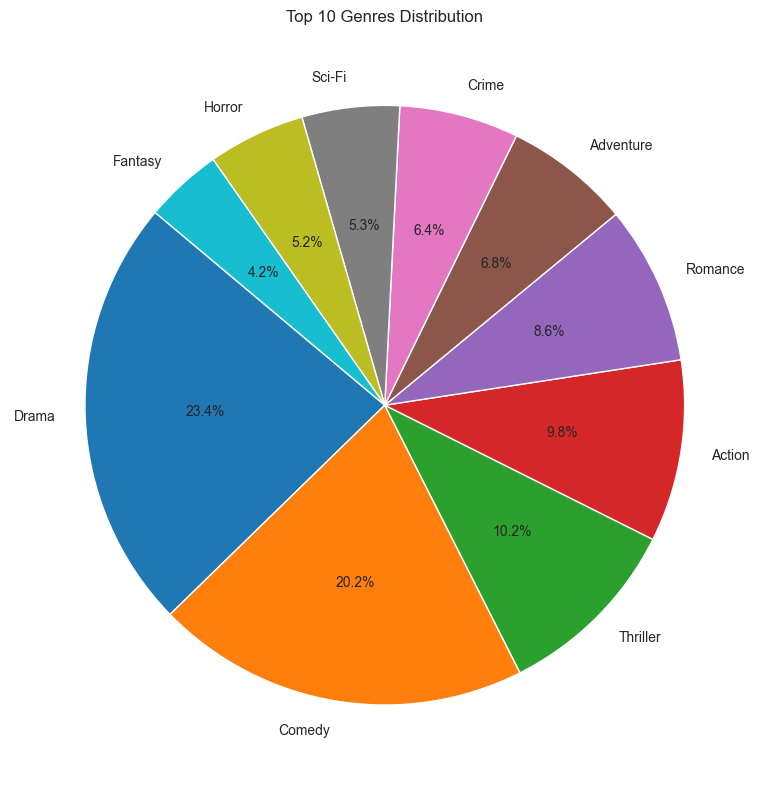

In [13]:
plt.figure(figsize=(8, 8))

plt.pie(
 top_genres["Count"],
 labels=top_genres["Genre"],
 autopct="%1.1f%%",
 startangle=140
)

plt.title(f"Top {top_x} Genres Distribution")
plt.tight_layout()

# Save BEFORE showing
chart_path = os.path.join(output_dir, "top_genres_pie_chart.png")
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()


## Step 12: Analyze Multi-Genre Movies

Find movies with multiple genres.

In [48]:
# Count number of genres per movie
movies_df['Genre_Count_Per_Movie'] = movies_df['Genres_List'].apply(len)

genre_count_distribution = (
 movies_df['Genre_Count_Per_Movie']
 .value_counts()
 .sort_index()
)

print(genre_count_distribution)


Genre_Count_Per_Movie
1     2851
2     3218
3     2338
4      987
5      271
6       63
7       12
8        1
10       1
Name: count, dtype: int64


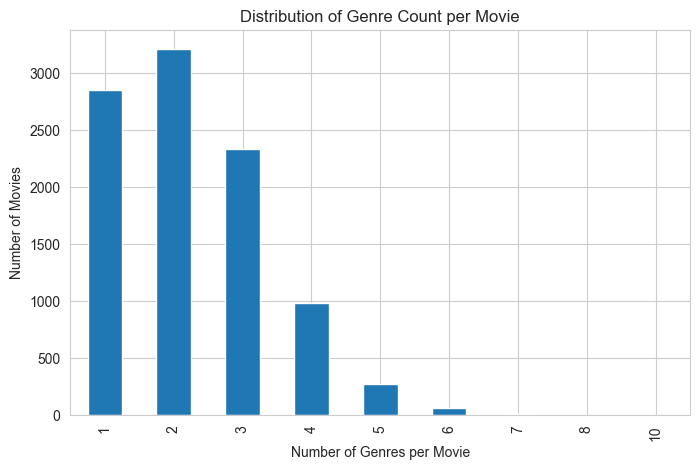

In [49]:
genre_count_distribution.plot(kind='bar', figsize=(8,5))
plt.xlabel("Number of Genres per Movie")
plt.ylabel("Number of Movies")
plt.title("Distribution of Genre Count per Movie")
plt.show()


In [50]:
genre_distribution = (
 movies_df['Genres_List']
 .explode()
 .value_counts()
)

print(genre_distribution)


Genres_List
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: count, dtype: int64


## Step 13: Create Comprehensive Excel Report

Export all analysis results to output directory.

In [ ]:
# --------------------------------
# Distribution of Genre Count per Movie
# --------------------------------

genre_count_distribution = (
    movies_df['Genre_Count_Per_Movie']
    .value_counts()
    .sort_index()
)

# Plot Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(
    genre_count_distribution.index,
    genre_count_distribution.values
)

plt.xlabel("Number of Genres per Movie")
plt.ylabel("Number of Movies")
plt.title("Distribution of Genre Count per Movie")
plt.tight_layout()

plt.savefig(os.path.join(output_dir, "genre_count_per_movie_distribution.png"), dpi=300)
plt.close()


# --------------------------------
# Distribution of Movies by Genre (Top 10)
# --------------------------------

genre_distribution = (
    movies_df['Genres_List']
    .explode()
    .value_counts()
)

top_x = 10
top_genres = genre_distribution.head(top_x)

plt.figure(figsize=(10, 6))
plt.bar(
    top_genres.index,
    top_genres.values
)

plt.xticks(rotation=45)
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.title(f"Top {top_x} Genres by Movie Count")
plt.tight_layout()

plt.savefig(os.path.join(output_dir, "top_10_genres_distribution.png"), dpi=300)
plt.close()

print(" Charts successfully generated and saved in:", output_dir)

## Summary

### What We Analyzed:
 Loaded MovieLens movies.csv dataset 
 Parsed pipe-separated genre data 
 Counted movies by genre 
 Created Excel tables with genre counts 
 Generated visualizations (bar chart, pie chart) 
 Analyzed multi-genre movies 
 Exported comprehensive Excel report 

### Output Files:
1. **genre_counts.xlsx** - Simple genre count table
2. **movielens_genre_analysis.xlsx** - Comprehensive report with:
 - Genre Counts sheet
 - Summary Statistics sheet
 - Genres per Movie distribution
 - Sample Movies dataset
3. **top_genres_bar.png** - Bar chart of top 15 genres
4. **top_genres_pie.png** - Pie chart of top 10 genres

### Key Insights:
- Total movies in dataset
- Number of unique genres
- Most/least common genres
- Average genres per movie
- Movies with most genres

### No LLM Required!
This notebook demonstrates pure data analysis with:
- **Pandas** - Data manipulation
- **Matplotlib** - Visualizations
- **Seaborn** - Enhanced styling
- **OpenPyXL** - Excel export